# Pseudo-GT Quality Gate（只读）

判断已通过 **Structural Acceptance** 的 object-level pseudo-GT 是否具有
**TD label quality**。对比仅 Reference / PartUV-Uniform / PseudoGT-TD
（同 chart hash / local UV / packer / padding / baker / 相机 / atlas 分辨率；
主公平轴 = 相同 B_raw，两档 50%/25%）。本 notebook **只读取** 质量门脚本
（`scripts/run_pseudo_gt_quality_gate.py`）产出的 JSON 与图片，不复制算法。

In [ ]:
import json, os
import matplotlib.pyplot as plt
from matplotlib.image import imread

SAMPLE_ID = "shoe_22b822__partuv_td_teacher_pseudo_gt_v1"
SD  = f"outputs/pseudo_gt/shoe_22b822_v1"
QD  = f"outputs/pseudo_gt_quality/{SAMPLE_ID}"

def jload(p):
    if not os.path.exists(p):
        print(f"[缺失] {p} —— 先运行 scripts/run_pseudo_gt_quality_gate.py")
        return None
    return json.load(open(p))

def show_png(p, figw=14):
    if not os.path.exists(p):
        print(f"[缺失] {p}"); return
    im = imread(p)
    plt.figure(figsize=(figw, figw * im.shape[0] / im.shape[1]))
    plt.imshow(im); plt.axis("off"); plt.show()

manifest = jload(f"{SD}/manifest.json")
metrics  = jload(f"{QD}/metrics.json")
report   = jload(f"{QD}/quality_report.json")
print(
    "加载:",
    "manifest" if manifest else "-", 
    "| metrics" if metrics else "-", 
    "| quality_report" if report else "-"
    )

加载: manifest | metrics | quality_report


## 1. Structural Acceptance（来自样本 manifest）

In [2]:
if manifest:
    print(f"sample_id: {manifest['sample_id']}")
    print(f"structural status: {manifest['status']}   "
          f"label={manifest['label_type']}  artist_gt={manifest['artist_gt']}")
    print(f"scope: {manifest['supervised_scope']}  "
          f"local_uv_refinement: {manifest['local_uv_refinement']}")
    print(f"teacher: {manifest['teacher']['name']} | beta={manifest['teacher']['beta']} "
          f"| packer={manifest['teacher']['packer']} | atlas={manifest['teacher']['atlas_size']}")
    print(f"chart_hash: {manifest['teacher']['chart_hash'][:20]}…")
    g = manifest['geometry']
    print(f"faces={g['n_faces']:,} charts={g['n_charts']} "
          f"coverage={g['train_face_coverage']*100:.3f}% reload_ok={g['reload_ok']}")
    n_gate = len(manifest['gates']); n_pass = sum(map(bool, manifest['gates'].values()))
    print(f"structural gates: {n_pass}/{n_gate} PASS")

sample_id: shoe_22b822__partuv_td_teacher_pseudo_gt_v1
structural status: ACCEPTED   label=partuv_td_teacher_pseudo_gt_v1  artist_gt=False
scope: td_allocation_only  local_uv_refinement: none
teacher: PartUV+TD Simple V1 | beta=0.75 | packer=xatlas | atlas=[1136, 1136]
chart_hash: 10fb27e3b48781206a45…
faces=14,458 charts=223 coverage=99.959% reload_ok=True
structural gates: 28/28 PASS


## 2. 2D Layout 与预算（同 B_raw，两档）

—— 50pct: B_raw=524,176 (两方法相同, 偏差 0.00%) ——
  PartUV-Uniform   B_signal=228,243  fill=43.5%  overlap=0
  PseudoGT-TD      B_signal=253,299  fill=48.3%  overlap=0
—— 25pct: B_raw=262,144 (两方法相同, 偏差 0.00%) ——
  PartUV-Uniform   B_signal=108,595  fill=41.4%  overlap=0
  PseudoGT-TD      B_signal=112,830  fill=43.0%  overlap=0


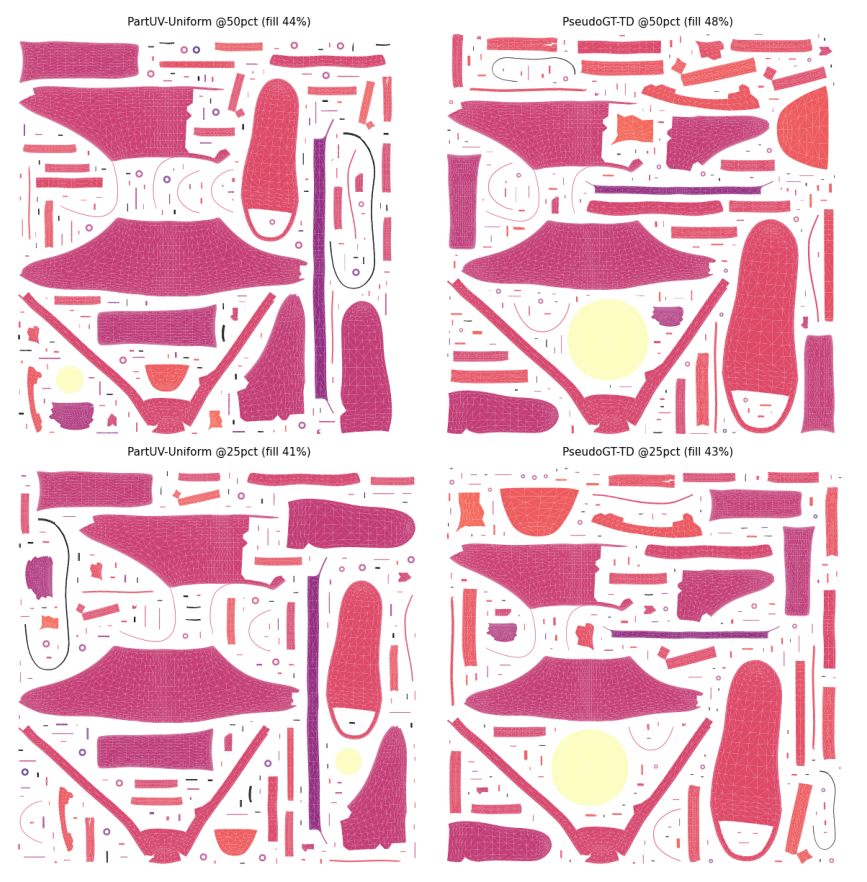

In [3]:
if metrics:
    for t, row in metrics["tiers"].items():
        print(f"—— {t}: B_raw={row['B_raw']:,} (两方法相同, 偏差 {row['braw_dev']*100:.2f}%) ——")
        for m, v in row["methods"].items():
            print(f"  {m:16s} B_signal={v['B_signal']:,}  fill={v['packing_fill']*100:.1f}%  "
                  f"overlap={v['overlap']}")
show_png(f"{QD}/layout_comparison.png", figw=11)

## 3. Global / HF / Seam 指标（线性 RGB；LPIPS 不可用 → masked SSIM，已标注）

In [4]:
if metrics:
    for t, row in metrics["tiers"].items():
        print(f"—— {t} ——")
        for m, v in row["methods"].items():
            print(f"  {m:16s} PSNR={v['psnr_db']}dB  HF MSE={v['mse_hf']:.3e}  "
                  f"seam MSE={v['mse_seam']:.3e}  interior={v['mse_interior']:.3e}  "
                  f"maskedSSIM={v['masked_ssim_mean']}")
        print(f"  G_global={row['G_global']:+.3f}   G_HF={row['G_HF']:+.3f}")
    print(f"\nsignal_dist(demand vs 面积分布)={metrics['signal_dist']:.3f} "
          f"(< {metrics['protocol']['low_signal_dist']} 判 LOW_SIGNAL)")

—— 50pct ——
  PartUV-Uniform   PSNR=29.39dB  HF MSE=6.026e-03  seam MSE=1.586e-03  interior=8.269e-04  maskedSSIM=0.97
  PseudoGT-TD      PSNR=30.89dB  HF MSE=1.660e-03  seam MSE=1.164e-03  interior=5.558e-04  maskedSSIM=0.9781
  G_global=+0.292   G_HF=+0.725
—— 25pct ——
  PartUV-Uniform   PSNR=27.69dB  HF MSE=7.626e-03  seam MSE=2.214e-03  interior=1.321e-03  maskedSSIM=0.9598
  PseudoGT-TD      PSNR=28.73dB  HF MSE=3.171e-03  seam MSE=1.810e-03  interior=9.901e-04  maskedSSIM=0.9689
  G_global=+0.212   G_HF=+0.584

signal_dist(demand vs 面积分布)=0.252 (< 0.05 判 LOW_SIGNAL)


## 4. 多视角渲染 / 误差热图 / 细节裁剪（50% 档）

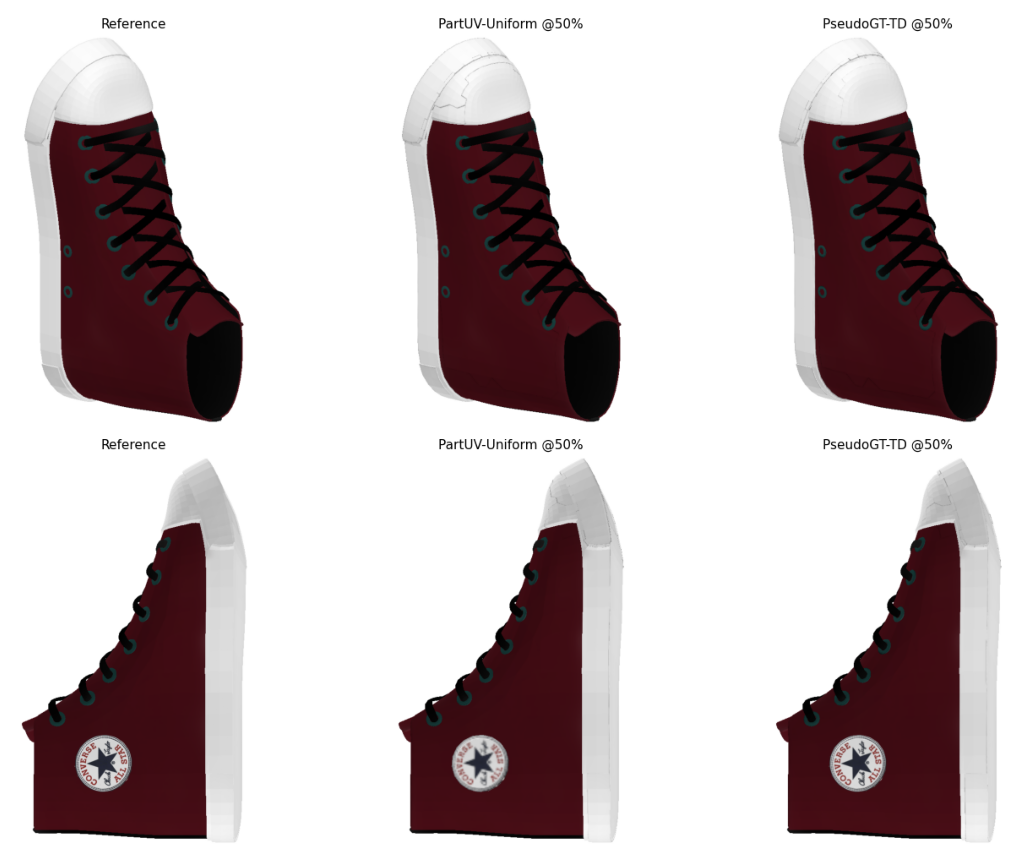

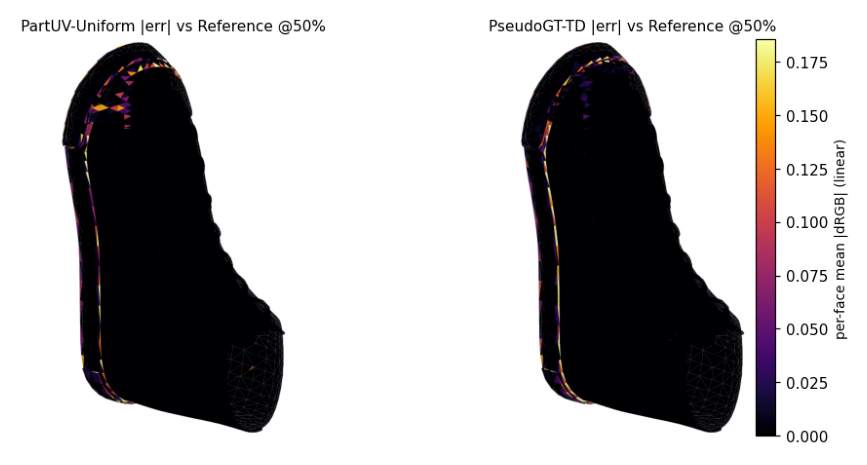

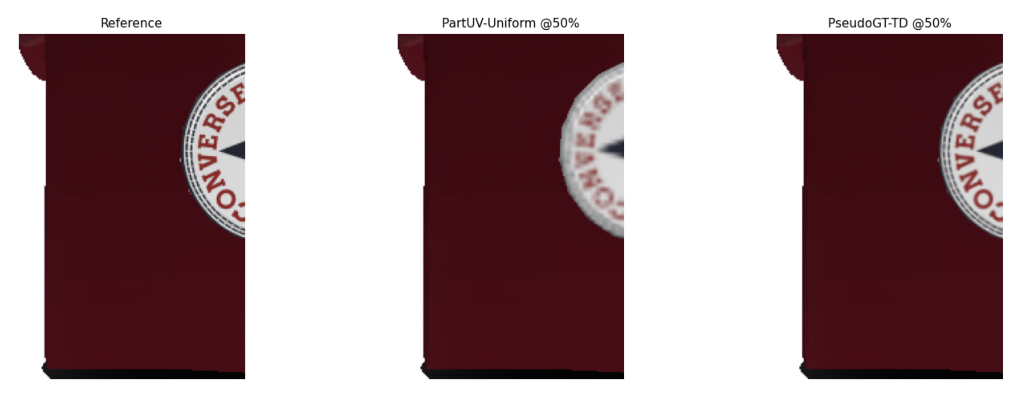

In [5]:
show_png(f"{QD}/render_comparison.png", figw=13)
show_png(f"{QD}/error_heatmap.png", figw=11)
show_png(f"{QD}/detail_crops.png", figw=13)

## 5. 最终 Quality Gate

In [6]:
if report:
    for t, gg in report["gates"].items():
        print(f"—— {t} ——")
        for k, v in gg.items():
            print(f"  [{'PASS' if v else 'FAIL'}] {k}")
    print(f"\nstructural_status = {report['structural_status']}")
    print(f"quality_status    = {report['quality_status']}")
    print(f"training_eligible = {report['training_eligible']}")
    print(f"protocol_hash     = {report['protocol_hash'][:20]}…")
    print(f"\n注: {report['notes']}")

—— 50pct ——
  [PASS] braw_dev<=1%
  [PASS] td_global<=1.02x_uniform
  [PASS] hf_gain>=5%_or_low_signal
  [PASS] masked_ssim_not_worse
  [PASS] fill_not_lower_2pp
  [PASS] no_overlap
—— 25pct ——
  [PASS] braw_dev<=1%
  [PASS] td_global<=1.02x_uniform
  [PASS] hf_gain>=5%_or_low_signal
  [PASS] masked_ssim_not_worse
  [PASS] fill_not_lower_2pp
  [PASS] no_overlap

structural_status = ACCEPTED
quality_status    = PASS
training_eligible = True
protocol_hash     = e268d7d20d6c9ad54ee6…

注: 对比仅 Reference/PartUV-Uniform/PseudoGT-TD; 同 chart hash/local UV/packer/padding/baker/相机/atlas 分辨率; 主公平轴=相同 B_raw; LPIPS 不可用, 用 foreground-masked SSIM 替代(已标注); surface 指标在线性 RGB 域; 未做 Blender/xatlas 重展开/ArtUV baseline(留待端到端 benchmark)。
